# Hackathon: Classification - Spambase dataset
 ----

Deadline     : 02.05.2026

 ----

Write the names and surnames of the members and the percentage of participation of each one in the development of the practice:
 - Integrante 1: Alejandro Muñoz
 - Integrante 2: Jeanpier Garay
 - Integrante 3: Cesar Castro

 ----

# Data Train and Data Test

By this point, your team should already have the training and testing data fully prepared for use in your model. Therefore, your team should focus solely on running your models and achieving good results.

# Model

Create your own soft SVM and hard SVM models and compare them with the Python library.

----

#### Remember, tu equipo puede usar pythorn y sklearn.

### 📘 Comparativa entre Regresión Logística y SVM en Scikit-learn

| Algoritmo               | Clase en Scikit-learn                                                                 | Documentación oficial                                                                                       | Ideal para...                                      |
|-------------------------|----------------------------------------------------------------------------------------|---------------------------------------------------------------------------------------------------------------|----------------------------------------------------|
| **Regresión logística** | [`LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) | [LogisticRegression Docs](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) | Problemas lineales, clasificación multiclase       |
| **SVM (kernel no lineal)** | [`SVC`](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html)                          | [SVC Docs](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html)                           | Problemas no lineales, alta precisión y robustez   |
| **SVM lineal (rápido)** | [`LinearSVC`](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html)                | [LinearSVC Docs](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html)               | Datos lineales o muy grandes                       |
| **SVM con parámetro ν** | [`NuSVC`](https://scikit-learn.org/stable/modules/generated/sklearn.svm.NuSVC.html)                        | [NuSVC Docs](https://scikit-learn.org/stable/modules/generated/sklearn.svm.NuSVC.html)                       | Alternativa a SVC, control explícito del margen    |


### 0. Importando Dataset

In [1]:
# Write here your o yours models.
!pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
spambase = fetch_ucirepo(id=94)

# data (as pandas dataframes)
X = spambase.data.features
y = spambase.data.targets

# metadata
print(spambase.metadata)

# variable information
print(spambase.variables)


{'uci_id': 94, 'name': 'Spambase', 'repository_url': 'https://archive.ics.uci.edu/dataset/94/spambase', 'data_url': 'https://archive.ics.uci.edu/static/public/94/data.csv', 'abstract': 'Classifying Email as Spam or Non-Spam', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 4601, 'num_features': 57, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1999, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C53G6X', 'creators': ['Mark Hopkins', 'Erik Reeber', 'George Forman', 'Jaap Suermondt'], 'intro_paper': None, 'additional_info': {'summary': 'The "spam" concept is diverse: advertisements for products/web sites, make money fast schemes, chain letters, pornography...\n\nThe classification task for this dataset is to determine whether a given email is spam or not.\n\t\nOur collecti

### 1. EDA

In [3]:
# Write your code here
import pandas as pd
X = pd.DataFrame(spambase.data.features)
y = pd.DataFrame(spambase.data.targets)
df = pd.concat([X,y], axis=1)

In [4]:
df['Class'].value_counts()

,count
Class,
0,2788
1,1813


In [5]:
df.isnull().sum()

,0
word_freq_make,0
word_freq_address,0
word_freq_all,0
word_freq_3d,0
word_freq_our,0
word_freq_over,0
word_freq_remove,0
word_freq_internet,0
word_freq_order,0
word_freq_mail,0


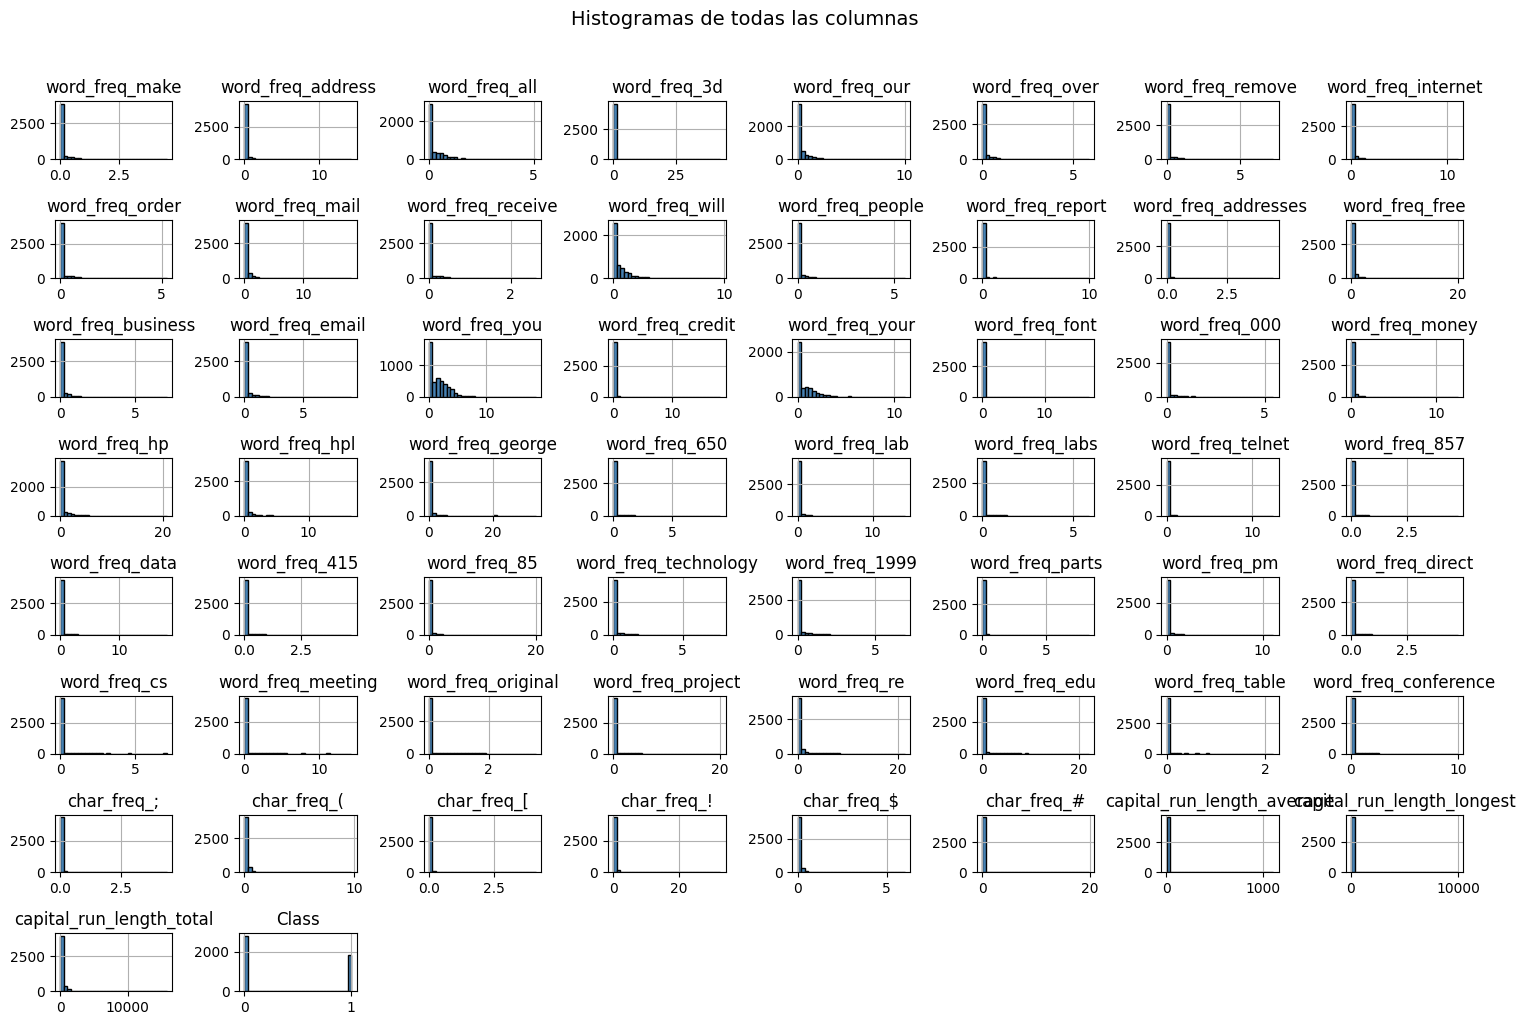

In [6]:
import matplotlib.pyplot as plt

df.hist(figsize=(15, 10), bins=30, edgecolor='black', color='steelblue')
plt.suptitle('Histogramas de todas las columnas', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
cantidad_zeros = []
for col in df.drop(columns='Class').columns:
  pct_ceros = (df[col] == 0).mean() * 100
  val = {'Columna': col, 'Zeros': pct_ceros}
  cantidad_zeros.append(val)
cantidad_zeros = pd.DataFrame(cantidad_zeros)
cantidad_zeros.sort_values(by='Zeros', ascending=False)


,Columna,Zeros
3,word_freq_3d,98.978483
46,word_freq_table,98.630732
37,word_freq_parts,98.196044
21,word_freq_font,97.457075
40,word_freq_cs,96.783308
47,word_freq_conference,95.587916
31,word_freq_857,95.544447
33,word_freq_415,95.327103
30,word_freq_telnet,93.631819
43,word_freq_project,92.892849


### 2. Normalización del dataset

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


X_ini = pd.DataFrame(spambase.data.features)
y_ini = pd.DataFrame(spambase.data.targets)
df = pd.concat([X_ini, y_ini], axis=1)

# 1. Crear features binarias
word_cols = [c for c in df.columns if c.startswith('word_freq_') or c.startswith('char_freq_')]

high_zero_cols = []
low_zero_cols  = []

for col in word_cols:
    pct = (df[col] == 0).mean() * 100
    if pct > 70:
        high_zero_cols.append(col)
    else:
        low_zero_cols.append(col)

print(f"Columnas → binaria:  {len(high_zero_cols)}")
print(f"Columnas → imputar:  {len(low_zero_cols)}")

# 2. Crear features binarias solo para high_zero_cols
for col in high_zero_cols:
    df[f'{col}_presente'] = (df[col] > 0).astype(int)

# Eliminar las originales de high_zero (las de low_zero se quedan)
df = df.drop(columns=high_zero_cols)

# Matriz de Correlación
corr_target = df.corr()['Class'].drop('Class').sort_values(key=abs, ascending=False)

# Features con correlación
umbral = 0.05
features_sin_impacto = corr_target[corr_target.abs() < umbral].index.tolist()
print(f"\nFeatures con |corr| < {umbral} → eliminando {len(features_sin_impacto)} columnas:")
print(features_sin_impacto)

df = df.drop(columns=features_sin_impacto);

Columnas → binaria:  46
Columnas → imputar:  8

Features con |corr| < 0.05 → eliminando 6 columnas:
['char_freq_;_presente', 'word_freq_direct_presente', 'word_freq_re_presente', 'word_freq_table_presente', 'word_freq_will', 'word_freq_parts_presente']


In [9]:
# 4. Separar X e y
X = df.drop(columns='Class').values
y = df['Class'].values
feature_cols = df.drop(columns='Class').columns.tolist()

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


# 4. Utilizar Standar Scaler para el dataset
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)
print("Nulls train:", np.isnan(X_train).sum())
print("Nulls val:  ", np.isnan(X_val).sum())
print("Nulls test: ", np.isnan(X_test).sum())

Train: (3220, 51)
Val:   (690, 51)
Test:  (691, 51)
Nulls train: 0
Nulls val:   0
Nulls test:  0


In [13]:
X_train

array([[-0.55029963, -0.44809425,  1.80338613, ..., -0.2171508 ,
        -0.36141109, -0.44136741],
       [-0.55029963, -0.44809425, -0.92424533, ..., -0.2171508 ,
        -0.36141109, -0.44136741],
       [ 0.09209042, -0.44809425,  0.55438856, ..., -0.2171508 ,
        -0.36141109,  2.26568606],
       ...,
       [-0.55029963,  1.74719283, -0.08971332, ..., -0.2171508 ,
        -0.36141109, -0.44136741],
       [-0.55029963, -0.44809425, -0.79542495, ..., -0.2171508 ,
        -0.36141109, -0.44136741],
       [ 0.24782134, -0.30075955, -0.92424533, ..., -0.2171508 ,
        -0.36141109, -0.44136741]])

### 3. Regresión Logística

#### 3.1 Regresión Logística (Scikit-Learn)

VALIDACIÓN
Accuracy: 0.9159
              precision    recall  f1-score   support

     No Spam       0.90      0.96      0.93       399
        Spam       0.94      0.86      0.90       291

    accuracy                           0.92       690
   macro avg       0.92      0.91      0.91       690
weighted avg       0.92      0.92      0.92       690

TEST
Accuracy: 0.9320
              precision    recall  f1-score   support

     No Spam       0.92      0.96      0.94       405
        Spam       0.94      0.89      0.92       286

    accuracy                           0.93       691
   macro avg       0.93      0.93      0.93       691
weighted avg       0.93      0.93      0.93       691



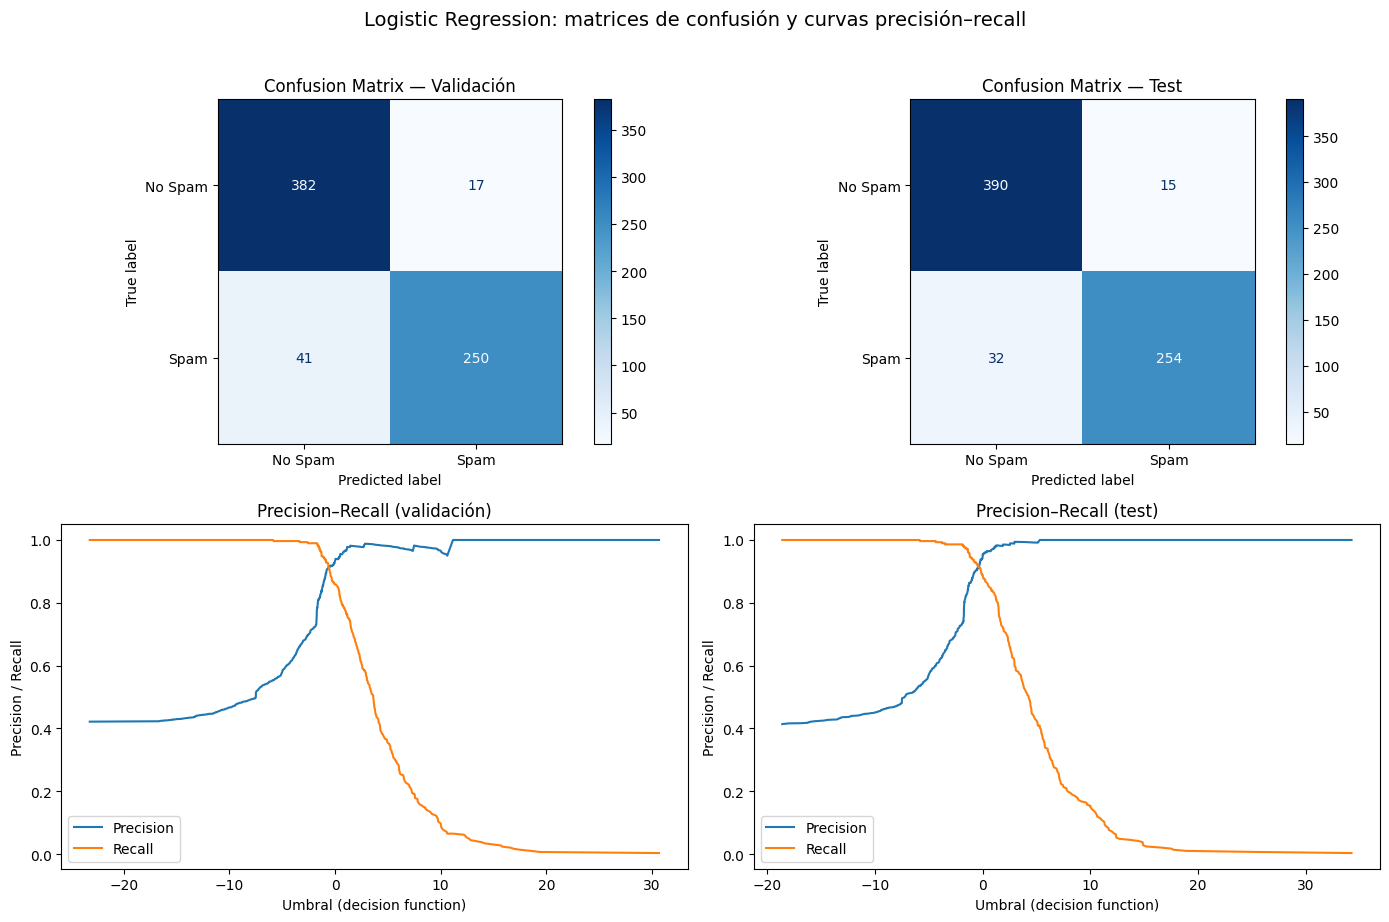

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
)
import matplotlib.pyplot as plt
import numpy as np

# 1. Entrenar
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)

# 2. Predicciones
y_pred_val  = lr.predict(X_val)
y_pred_test = lr.predict(X_test)
y_scores_val = lr.decision_function(X_val)
y_scores_test = lr.decision_function(X_test)

# 3. Métricas
acc_val_lr   = accuracy_score(y_val, y_pred_val)
prec_val_lr  = precision_score(y_val, y_pred_val, average="macro", zero_division=0)
rec_val_lr   = recall_score(y_val, y_pred_val, average="macro", zero_division=0)
f1_val_lr    = f1_score(y_val, y_pred_val, average="macro", zero_division=0)

print("=" * 50)
print("VALIDACIÓN")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_val, y_pred_val):.4f}")
print(classification_report(y_val, y_pred_val, target_names=['No Spam', 'Spam']))

print("=" * 50)
print("TEST")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(classification_report(y_test, y_pred_test, target_names=['No Spam', 'Spam']))

# 4. Gráficos
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Confusion matrix Val
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_val,
    display_labels=['No Spam', 'Spam'],
    cmap='Blues', ax=axes[0, 0]
)
axes[0, 0].set_title('Confusion Matrix — Validación')

# Confusion matrix Test
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=['No Spam', 'Spam'],
    cmap='Blues', ax=axes[0, 1]
)
axes[0, 1].set_title('Confusion Matrix — Test')

# Precision–Recall vs umbral (validación)
precisions_val, recalls_val, pr_thresholds_val = precision_recall_curve(
    np.ravel(y_val), y_scores_val
)
axes[1, 0].plot(pr_thresholds_val, precisions_val[:-1], label='Precision')
axes[1, 0].plot(pr_thresholds_val, recalls_val[:-1], label='Recall')
axes[1, 0].legend()
axes[1, 0].set_title('Precision–Recall (validación)')
axes[1, 0].set_xlabel('Umbral (decision function)')
axes[1, 0].set_ylabel('Precision / Recall')

# Precision–Recall vs umbral (test)
precisions_test, recalls_test, pr_thresholds_test = precision_recall_curve(
    np.ravel(y_test), y_scores_test
)
axes[1, 1].plot(pr_thresholds_test, precisions_test[:-1], label='Precision')
axes[1, 1].plot(pr_thresholds_test, recalls_test[:-1], label='Recall')
axes[1, 1].legend()
axes[1, 1].set_title('Precision–Recall (test)')
axes[1, 1].set_xlabel('Umbral (decision function)')
axes[1, 1].set_ylabel('Precision / Recall')

fig.suptitle("Logistic Regression: matrices de confusión y curvas precisión–recall", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


#### 3.2 Regresión Logística (Manual)

### 4. SVM

#### 4.1 SVM (Kernel no lineal)

VALIDACIÓN
Accuracy: 0.9406
              precision    recall  f1-score   support

     No Spam       0.93      0.96      0.95       399
        Spam       0.95      0.91      0.93       291

    accuracy                           0.94       690
   macro avg       0.94      0.94      0.94       690
weighted avg       0.94      0.94      0.94       690

TEST
Accuracy: 0.9465
              precision    recall  f1-score   support

     No Spam       0.94      0.97      0.96       405
        Spam       0.96      0.91      0.93       286

    accuracy                           0.95       691
   macro avg       0.95      0.94      0.94       691
weighted avg       0.95      0.95      0.95       691



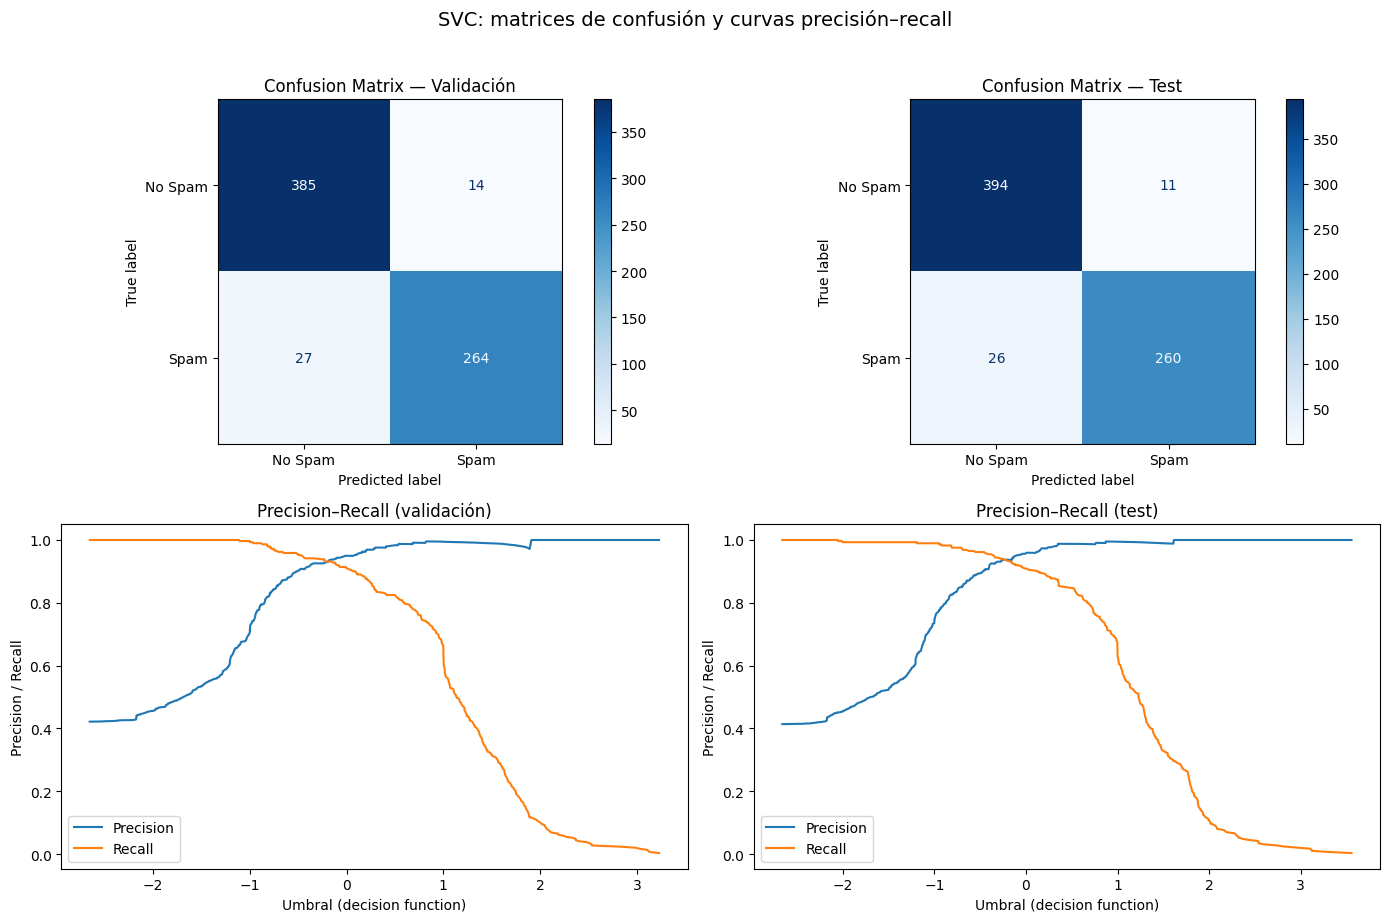

In [ ]:
from sklearn.svm import SVC

# 1. Entrenar
clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
clf.fit(X_train, y_train)

# 2. Predicciones
y_pred_val  = clf.predict(X_val)
y_pred_test = clf.predict(X_test)
y_scores_val = clf.decision_function(X_val)
y_scores_test = clf.decision_function(X_test)

# 3. Métricas
acc_val_svm_nl   = accuracy_score(y_val, y_pred_val)
prec_val_svm_nl  = precision_score(y_val, y_pred_val, average="macro", zero_division=0)
rec_val_svm_nl   = recall_score(y_val, y_pred_val, average="macro", zero_division=0)
f1_val_svm_nl    = f1_score(y_val, y_pred_val, average="macro", zero_division=0)

print("=" * 50)
print("VALIDACIÓN")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_val, y_pred_val):.4f}")
print(classification_report(y_val, y_pred_val, target_names=['No Spam', 'Spam']))

print("=" * 50)
print("TEST")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(classification_report(y_test, y_pred_test, target_names=['No Spam', 'Spam']))

# 4. Gráficos
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Confusion matrix Val
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_val,
    display_labels=['No Spam', 'Spam'],
    cmap='Blues', ax=axes[0, 0]
)
axes[0, 0].set_title('Confusion Matrix — Validación')

# Confusion matrix Test
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=['No Spam', 'Spam'],
    cmap='Blues', ax=axes[0, 1]
)
axes[0, 1].set_title('Confusion Matrix — Test')

# Precision–Recall vs umbral (validación)
precisions_val, recalls_val, pr_thresholds_val = precision_recall_curve(
    np.ravel(y_val), y_scores_val
)
axes[1, 0].plot(pr_thresholds_val, precisions_val[:-1], label='Precision')
axes[1, 0].plot(pr_thresholds_val, recalls_val[:-1], label='Recall')
axes[1, 0].legend()
axes[1, 0].set_title('Precision–Recall (validación)')
axes[1, 0].set_xlabel('Umbral (decision function)')
axes[1, 0].set_ylabel('Precision / Recall')

# Precision–Recall vs umbral (test)
precisions_test, recalls_test, pr_thresholds_test = precision_recall_curve(
    np.ravel(y_test), y_scores_test
)
axes[1, 1].plot(pr_thresholds_test, precisions_test[:-1], label='Precision')
axes[1, 1].plot(pr_thresholds_test, recalls_test[:-1], label='Recall')
axes[1, 1].legend()
axes[1, 1].set_title('Precision–Recall (test)')
axes[1, 1].set_xlabel('Umbral (decision function)')
axes[1, 1].set_ylabel('Precision / Recall')

fig.suptitle("SVC: matrices de confusión y curvas precisión–recall", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


#### 4.2 SVM lineal (rápido)

VALIDACIÓN
Accuracy: 0.9159
              precision    recall  f1-score   support

     No Spam       0.90      0.95      0.93       399
        Spam       0.93      0.86      0.90       291

    accuracy                           0.92       690
   macro avg       0.92      0.91      0.91       690
weighted avg       0.92      0.92      0.92       690

TEST
Accuracy: 0.9334
              precision    recall  f1-score   support

     No Spam       0.92      0.97      0.94       405
        Spam       0.95      0.88      0.92       286

    accuracy                           0.93       691
   macro avg       0.94      0.93      0.93       691
weighted avg       0.93      0.93      0.93       691



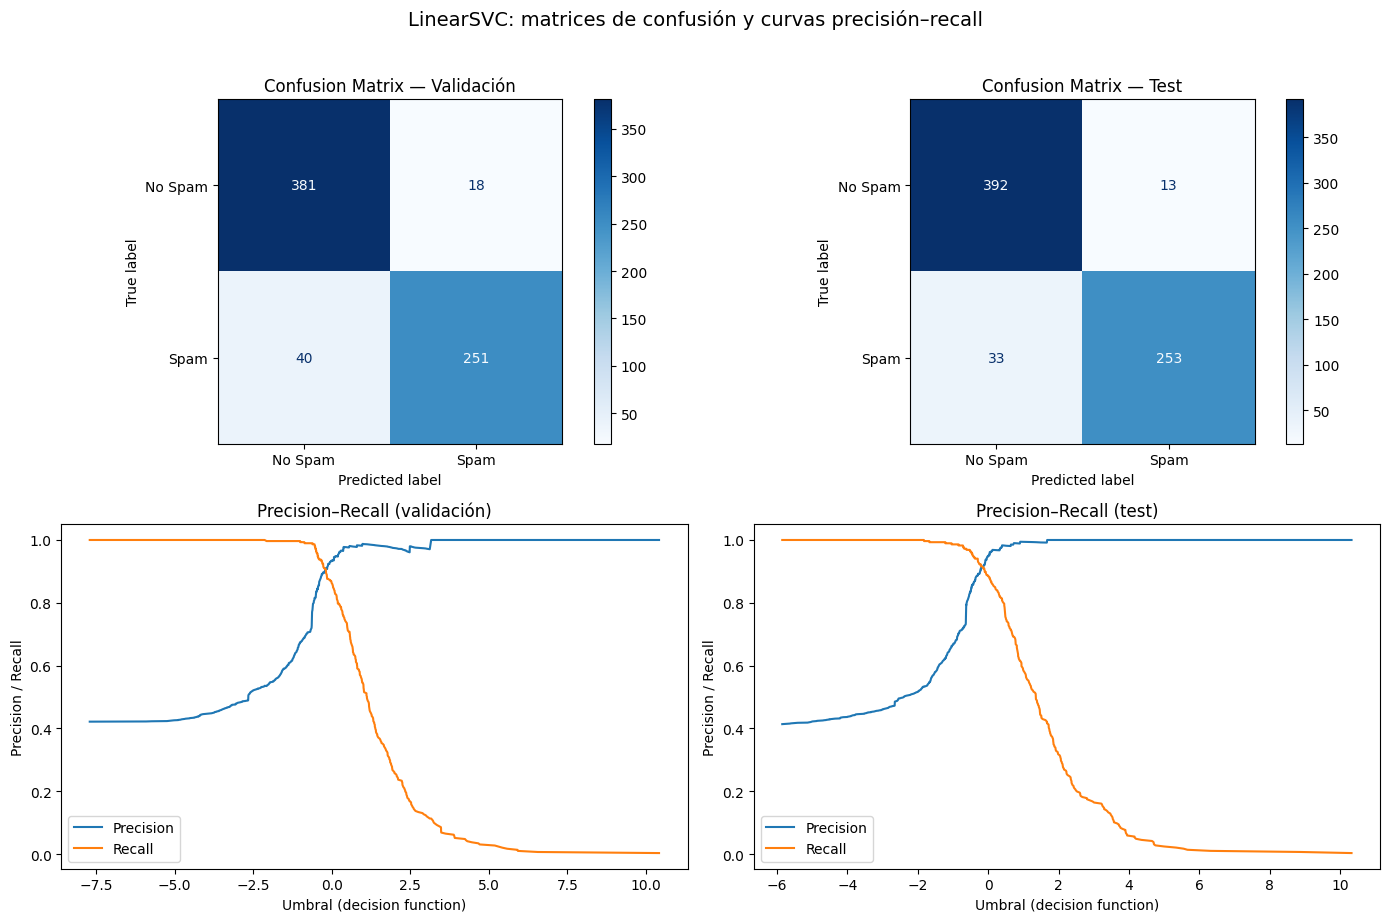

In [ ]:
from sklearn.svm import LinearSVC

# 1. Entrenar
clf = LinearSVC(random_state=42, tol=1e-5)
clf.fit(X_train, y_train)

# 2. Predicciones
y_pred_val  = clf.predict(X_val)
y_pred_test = clf.predict(X_test)
y_scores_val = clf.decision_function(X_val)
y_scores_test = clf.decision_function(X_test)

# 3. Métricas
acc_val_svm_l   = accuracy_score(y_val, y_pred_val)
prec_val_svm_l  = precision_score(y_val, y_pred_val, average="macro", zero_division=0)
rec_val_svm_l   = recall_score(y_val, y_pred_val, average="macro", zero_division=0)
f1_val_svm_l    = f1_score(y_val, y_pred_val, average="macro", zero_division=0)

print("=" * 50)
print("VALIDACIÓN")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_val, y_pred_val):.4f}")
print(classification_report(y_val, y_pred_val, target_names=['No Spam', 'Spam']))

print("=" * 50)
print("TEST")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(classification_report(y_test, y_pred_test, target_names=['No Spam', 'Spam']))

# 4. Gráficos
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Confusion matrix Val
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_val,
    display_labels=['No Spam', 'Spam'],
    cmap='Blues', ax=axes[0, 0]
)
axes[0, 0].set_title('Confusion Matrix — Validación')

# Confusion matrix Test
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=['No Spam', 'Spam'],
    cmap='Blues', ax=axes[0, 1]
)
axes[0, 1].set_title('Confusion Matrix — Test')

# Precision–Recall vs umbral (validación)
precisions_val, recalls_val, pr_thresholds_val = precision_recall_curve(
    np.ravel(y_val), y_scores_val
)
axes[1, 0].plot(pr_thresholds_val, precisions_val[:-1], label='Precision')
axes[1, 0].plot(pr_thresholds_val, recalls_val[:-1], label='Recall')
axes[1, 0].legend()
axes[1, 0].set_title('Precision–Recall (validación)')
axes[1, 0].set_xlabel('Umbral (decision function)')
axes[1, 0].set_ylabel('Precision / Recall')

# Precision–Recall vs umbral (test)
precisions_test, recalls_test, pr_thresholds_test = precision_recall_curve(
    np.ravel(y_test), y_scores_test
)
axes[1, 1].plot(pr_thresholds_test, precisions_test[:-1], label='Precision')
axes[1, 1].plot(pr_thresholds_test, recalls_test[:-1], label='Recall')
axes[1, 1].legend()
axes[1, 1].set_title('Precision–Recall (test)')
axes[1, 1].set_xlabel('Umbral (decision function)')
axes[1, 1].set_ylabel('Precision / Recall')

fig.suptitle("LinearSVC: matrices de confusión y curvas precisión–recall", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


#### 4.3 SVM con parámetro ν

VALIDACIÓN
Accuracy: 0.9014
              precision    recall  f1-score   support

     No Spam       0.88      0.96      0.92       399
        Spam       0.93      0.82      0.88       291

    accuracy                           0.90       690
   macro avg       0.91      0.89      0.90       690
weighted avg       0.90      0.90      0.90       690

TEST
Accuracy: 0.9161
              precision    recall  f1-score   support

     No Spam       0.90      0.97      0.93       405
        Spam       0.95      0.85      0.89       286

    accuracy                           0.92       691
   macro avg       0.92      0.91      0.91       691
weighted avg       0.92      0.92      0.92       691



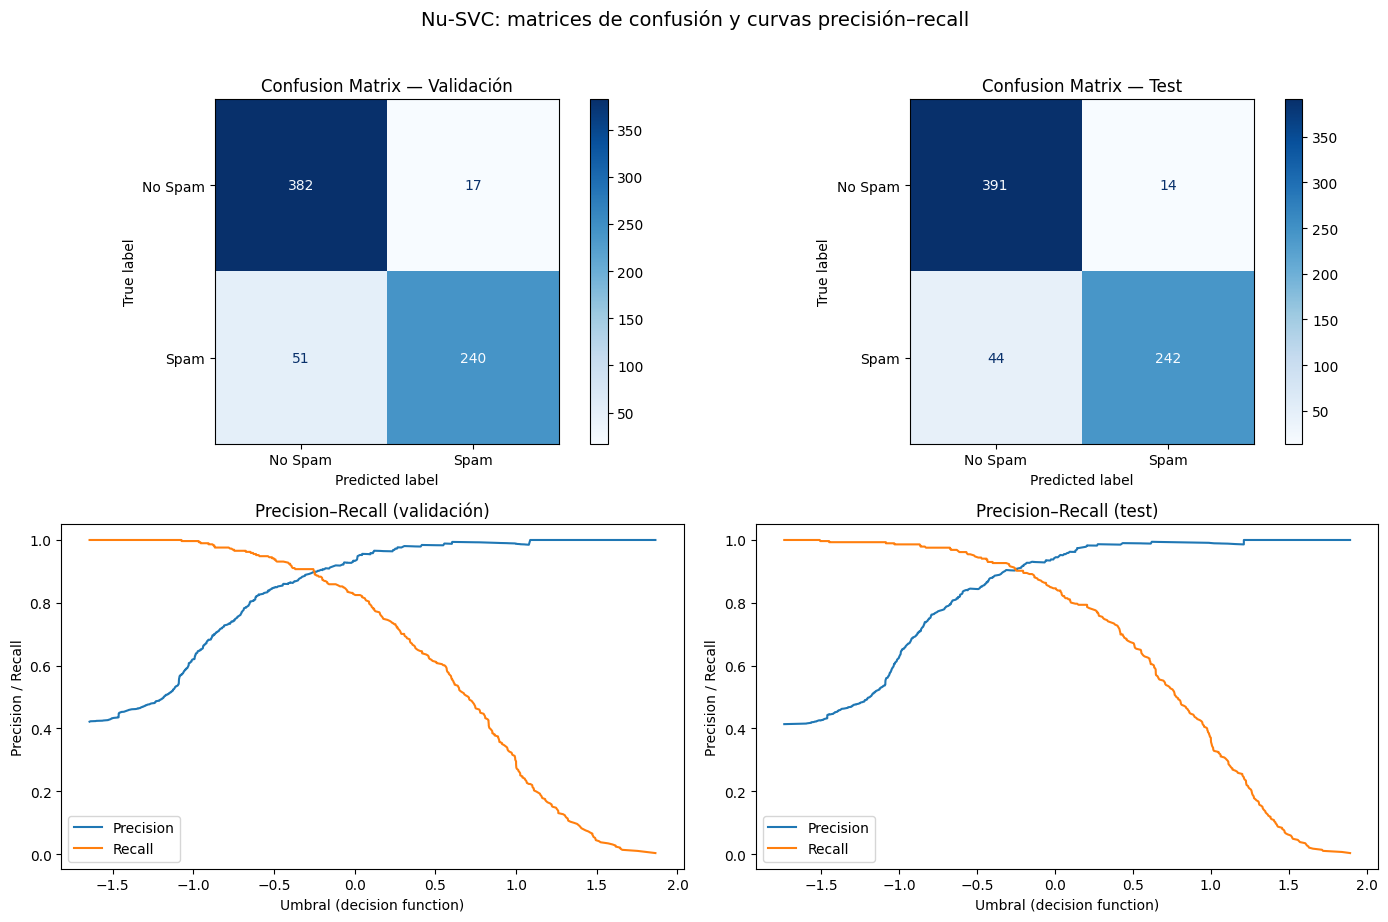

In [ ]:
from sklearn.svm import NuSVC

# 1. Entrenar
clf = NuSVC(random_state=42)
clf.fit(X_train, y_train)

# 2. Predicciones
y_pred_val  = clf.predict(X_val)
y_pred_test = clf.predict(X_test)
y_scores_val = clf.decision_function(X_val)
y_scores_test = clf.decision_function(X_test)

# 3. Métricas
acc_val_svm_v   = accuracy_score(y_val, y_pred_val)
prec_val_svm_v  = precision_score(y_val, y_pred_val, average="macro", zero_division=0)
rec_val_svm_v   = recall_score(y_val, y_pred_val, average="macro", zero_division=0)
f1_val_svm_v    = f1_score(y_val, y_pred_val, average="macro", zero_division=0)

print("=" * 50)
print("VALIDACIÓN")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_val, y_pred_val):.4f}")
print(classification_report(y_val, y_pred_val, target_names=['No Spam', 'Spam']))

print("=" * 50)
print("TEST")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(classification_report(y_test, y_pred_test, target_names=['No Spam', 'Spam']))

# 4. Gráficos
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Confusion matrix Val
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_val,
    display_labels=['No Spam', 'Spam'],
    cmap='Blues', ax=axes[0, 0]
)
axes[0, 0].set_title('Confusion Matrix — Validación')

# Confusion matrix Test
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=['No Spam', 'Spam'],
    cmap='Blues', ax=axes[0, 1]
)
axes[0, 1].set_title('Confusion Matrix — Test')

# Precision–Recall vs umbral (validación)
precisions_val, recalls_val, pr_thresholds_val = precision_recall_curve(
    np.ravel(y_val), y_scores_val
)
axes[1, 0].plot(pr_thresholds_val, precisions_val[:-1], label='Precision')
axes[1, 0].plot(pr_thresholds_val, recalls_val[:-1], label='Recall')
axes[1, 0].legend()
axes[1, 0].set_title('Precision–Recall (validación)')
axes[1, 0].set_xlabel('Umbral (decision function)')
axes[1, 0].set_ylabel('Precision / Recall')

# Precision–Recall vs umbral (test)
precisions_test, recalls_test, pr_thresholds_test = precision_recall_curve(
    np.ravel(y_test), y_scores_test
)
axes[1, 1].plot(pr_thresholds_test, precisions_test[:-1], label='Precision')
axes[1, 1].plot(pr_thresholds_test, recalls_test[:-1], label='Recall')
axes[1, 1].legend()
axes[1, 1].set_title('Precision–Recall (test)')
axes[1, 1].set_xlabel('Umbral (decision function)')
axes[1, 1].set_ylabel('Precision / Recall')

fig.suptitle("Nu-SVC: matrices de confusión y curvas precisión–recall", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


#### 4.4 Comparativa entre los tres SVM (validación y test)

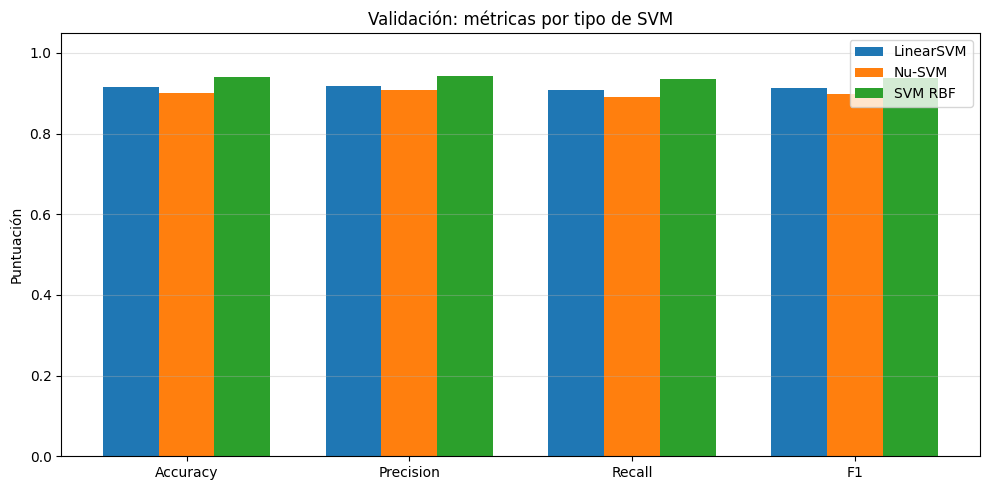

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Orden de filas: ajusta etiquetas según l = lineal, v = ν (Nu), nl = RBF
nombres = ["LinearSVM", "Nu-SVM", "SVM RBF"]
etiquetas = ["Accuracy", "Precision", "Recall", "F1"]

datos = np.array(
    [
        [acc_val_svm_l, prec_val_svm_l, rec_val_svm_l, f1_val_svm_l],
        [acc_val_svm_v, prec_val_svm_v, rec_val_svm_v, f1_val_svm_v],
        [acc_val_svm_nl, prec_val_svm_nl, rec_val_svm_nl, f1_val_svm_nl],
    ],
    dtype=float,
)

x = np.arange(len(etiquetas))
ancho = 0.25
fig, ax = plt.subplots(figsize=(10, 5))

for i, nombre in enumerate(nombres):
    offset = (i - 1) * ancho
    ax.bar(x + offset, datos[i], ancho, label=nombre)

ax.set_xticks(x)
ax.set_xticklabels(etiquetas)
ax.set_ylabel("Puntuación")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis="y", alpha=0.35)
ax.set_title("Validación: métricas por tipo de SVM")
plt.tight_layout()
plt.show()

#### 4.5 SVM Manual

In [14]:
def S(x,w,b):
  return x@w+b

In [15]:
def Loss(x,y,w,b,C):
  hiphotesis = S(x,w,b)
  margin = 1 - hiphotesis*y
  return ((np.linalg.norm(w))**2/2) + C*np.sum(np.maximum(margin,0))

In [16]:
def derivative(x,y,w,b,C):
  scores = S(x, w, b)
  margins = y * scores

  mask = margins < 1

  dw = w- C * np.sum((y[mask][:, None] * x[mask]), axis=0)

  db =-C * np.sum(y[mask])

  return dw, db

In [17]:
def update(w,b,dw,db,lr):
  w = w - lr*dw
  b = b - lr*db
  return w,b

In [18]:
def divide_data(x,y):
  train_index = np.random.choice(np.arange(len(x)),int(len(x)*0.7),replace=False)
  rest_index = np.delete(np.arange(len(x)),train_index)
  val_index = np.random.choice(rest_index,int(len(rest_index)*0.6),replace=False)
  for i in range(len(val_index)):
    rest_index = rest_index[rest_index != val_index[i]]
  test_index = rest_index
  return x[train_index],y[train_index],x[val_index],y[val_index],x[test_index],y[test_index]

In [31]:
def evaluar(y_pred_test, y_test,scores):
  from sklearn.model_selection import train_test_split
  from sklearn.svm import SVC
  from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                               classification_report, ConfusionMatrixDisplay, precision_recall_curve,
                               confusion_matrix, ConfusionMatrixDisplay,roc_curve,auc)
  import matplotlib.pyplot as plt
  import numpy as np

  # ── 3. Métricas ───────────────────────────────────────────────────────────────
  print("=" * 50)
  print("MÉTRICAS")
  print("=" * 50)
  print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
  print(classification_report(y_test, y_pred_test, target_names=['No Spam', 'Spam']))

  # ── 4. Gráficos ───────────────────────────────────────────────────────────────
  fig, axes = plt.subplots(1, 3, figsize=(12, 4))

  # Confusion matrix Val
  ConfusionMatrixDisplay.from_predictions(
      y_test, y_pred_test,
      display_labels=['No Spam', 'Spam'],
      cmap='Blues', ax=axes[0]
  )
  axes[0].set_title('Confusion Matrix — Validación')

  precisions,recalls,thershold = precision_recall_curve((y_test==1).astype(int), scores)
  f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

  fpr, tpr, thresholds_roc = roc_curve((y_test==1).astype(int), scores)
  roc_auc = auc(fpr, tpr)

  axes[1].plot(thershold,precisions[:-1],label='precision')
  axes[1].plot(thershold,recalls[:-1],label='recalls')
  axes[1].plot(thershold,f1_scores[:-1],label='f1_score')
  axes[1].legend()
  axes[1].grid()
  axes[1].set_title('Precision-Recall Curve')
  axes[1].set_xlabel('Thershold')
  axes[1].set_ylabel('Precision/Recall')

  axes[2].plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
  axes[2].plot([0, 1], [0, 1], linestyle='--')
  axes[2].set_title('ROC Curve')
  axes[2].set_xlabel('False Positive Rate')
  axes[2].set_ylabel('True Positive Rate')
  axes[2].legend()

  plt.tight_layout()
  plt.yticks(np.linspace(0, np.max(recalls[:-1]), 20))
  plt.grid(10)
  plt.show()

In [20]:
def train(x_train,y_train,x_val,y_val,x_test,y_test,epochs,alfa,C):
  np.random.seed(2001)
  W=np.random.randn(X.shape[1])
  b=np.random.randn()
  L_T=[]
  L_V=[]
  loss = []
  for i in range(epochs):
    dW, dB = derivative(x_train,y_train,W,b,C)
    W,b = update(W,b,dW,dB,alfa)
    loss_t = Loss(x_train,y_train,W,b,C)
    L_T.append(loss_t)
    loss_v = Loss(x_val,y_val,W,b,C)
    L_V.append(loss_v)

  scores = S(x_test, W,b)
  y_pred_test = np.where(scores >= 0, 1, -1)
  evaluar(y_pred_test, y_test,scores)

  return W,b,L_T,L_V

In [23]:
y_train = np.where(y_train == 0, -1, 1)
y_val = np.where(y_val == 0, -1, 1)
y_test = np.where(y_test == 0, -1, 1)

MÉTRICAS
Accuracy: 0.9334
              precision    recall  f1-score   support

     No Spam       0.92      0.97      0.94       405
        Spam       0.95      0.89      0.92       286

    accuracy                           0.93       691
   macro avg       0.94      0.93      0.93       691
weighted avg       0.93      0.93      0.93       691



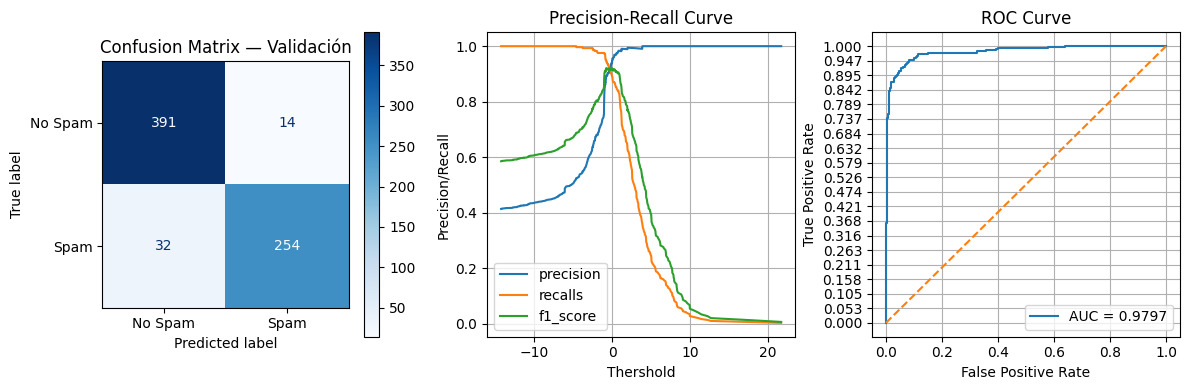

In [32]:
params,b,loss_t,loss_v=train(X_train,y_train,X_val,y_val,X_test,y_test,100000,0.0001,2)